<a href="https://colab.research.google.com/github/Adi324-Code/Machine-Learning/blob/main/Object_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!echo KGAT_e41d0200407e6bc49b5ea219a9cdc5f4 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [3]:
!kaggle competitions download -c cifar-10

100% 715M/715M [00:34<00:00, 21.5MB/s]



In [4]:
!ls

cifar-10.zip  sample_data


In [5]:
from zipfile import ZipFile

dataset = "/content/cifar-10.zip"

with ZipFile(dataset, "r") as zip:
    zip.extractall()
    print("dataset extracted")

dataset extracted


In [6]:
!ls

cifar-10.zip  sampleSubmission.csv  train.7z
sample_data   test.7z		    trainLabels.csv


In [7]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 17.1 MB/s eta 0:00:00


In [8]:
import py7zr
archive=py7zr.SevenZipFile('/content/train.7z',mode="r")
archive.extractall()

archive.close()

In [9]:
!ls

cifar-10.zip  sampleSubmission.csv  train     trainLabels.csv
sample_data   test.7z		    train.7z


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [11]:
filename=os.listdir("/content/train")

In [12]:
type(filename)

list

In [13]:
len(filename)

50000

In [14]:
print(filename[0:5])
print(filename[-5:])

['24538.png', '22160.png', '11470.png', '24656.png', '32050.png']
['1378.png', '14887.png', '159.png', '28779.png', '6268.png']


In [15]:
labels_df=pd.read_csv("/content/trainLabels.csv")

In [16]:
labels_df.shape

(50000, 2)

In [17]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [18]:
labels_df.tail()

,id,label
49995,49996,bird
49996,49997,frog
49997,49998,truck
49998,49999,automobile
49999,50000,automobile


In [19]:
labels_df["label"].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [20]:
label_dict={"frog":0,
            "truck":1,
            "deer":2,
            "automobile":3,
            "bird":4,
            "horse":5,
            "ship":6,
            "cat":7,
            "dog":8,
            "airplane":9}



In [21]:
labelx=[label_dict[i] for i in labels_df["label"]]

In [22]:
print(labelx[0:5])
print(labelx[-5:])

[0, 1, 1, 2, 3]
[4, 0, 1, 3, 3]


In [23]:
# image=mpimg.imread("/content/train/4458.png")
# imageplt=plt.imshow(image)
# plt.show()

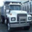

In [24]:
imagex=cv2.imread("/content/train/4458.png")
cv2_imshow(imagex)

In [25]:
labels_df[labels_df["id"]==4458]

,id,label
4457,4458,truck


In [26]:
id_list=list(labels_df["id"])

In [27]:
path="/content/train/"
data=[]

for id in id_list:
  image=Image.open(path+str(id)+".png")
  image=image.resize((32,32))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)



In [28]:
type(data)

list

In [29]:
len(data)

50000

array([[[ 43,  38,  18],
        [ 42,  38,  20],
        [ 38,  38,  20],
        ...,
        [ 30,  32,  12],
        [ 30,  32,  12],
        [ 32,  34,  12]],

       [[ 53,  42,  21],
        [ 53,  43,  22],
        [ 51,  46,  23],
        ...,
        [ 37,  36,  14],
        [ 37,  36,  14],
        [ 39,  37,  16]],

       [[ 62,  49,  25],
        [ 63,  50,  26],
        [ 61,  53,  27],
        ...,
        [ 43,  41,  16],
        [ 43,  41,  16],
        [ 45,  41,  18]],

       ...,

       [[ 92,  95,  84],
        [ 92,  95,  84],
        [ 89,  92,  82],
        ...,
        [101, 105,  90],
        [101, 105,  90],
        [100, 104,  89]],

       [[ 90,  94,  83],
        [ 91,  94,  82],
        [124, 127, 115],
        ...,
        [ 98, 103,  87],
        [ 98, 103,  87],
        [ 98, 102,  87]],

       [[ 90,  96,  84],
        [118, 121, 107],
        [179, 183, 168],
        ...,
        [104, 109,  91],
        [102, 107,  89],
        [108, 111,  93]]], dtype=uint8)
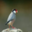

In [30]:
data[1777]

In [31]:
X=np.array(data)
Y=np.array(labelx)

In [32]:
print(X.shape)
print(Y.shape)

(50000, 32, 32, 3)
(50000,)


In [33]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [34]:
print(X_train)

[[[[209 210 203]
   [213 214 209]
   [218 219 215]
   ...
   [127  74  39]
   [122  68  35]
   [116  63  32]]

  [[210 210 202]
   [213 214 207]
   [218 220 214]
   ...
   [124  70  35]
   [121  67  33]
   [123  69  36]]

  [[206 205 195]
   [209 209 202]
   [213 215 209]
   ...
   [124  70  37]
   [131  77  42]
   [131  78  41]]

  ...

  [[127 108  97]
   [138 122 110]
   [141 127 118]
   ...
   [158 149 134]
   [161 156 151]
   [136 137 148]]

  [[145 130 119]
   [148 135 128]
   [136 127 128]
   ...
   [175 174 172]
   [160 161 170]
   [143 148 164]]

  [[138 128 123]
   [140 132 136]
   [136 131 140]
   ...
   [150 154 169]
   [145 149 166]
   [140 145 163]]]


 [[[187 207 240]
   [186 205 237]
   [188 207 240]
   ...
   [165 201 236]
   [163 198 235]
   [163 199 236]]

  [[193 212 243]
   [192 210 241]
   [194 212 243]
   ...
   [169 204 238]
   [167 202 238]
   [167 202 238]]

  [[198 214 244]
   [196 212 241]
   [198 214 243]
   ...
   [172 205 238]
   [170 203 236]
   [170 204

In [35]:
print(Y_train)

[7 6 6 ... 7 9 1]


In [36]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(40000, 32, 32, 3)
(40000,)
(10000, 32, 32, 3)
(10000,)


In [37]:
X_train_scaled=X_train/255
Y_train_scaled=Y_train/255

In [38]:
print(X_train_scaled)

[[[[0.81960784 0.82352941 0.79607843]
   [0.83529412 0.83921569 0.81960784]
   [0.85490196 0.85882353 0.84313725]
   ...
   [0.49803922 0.29019608 0.15294118]
   [0.47843137 0.26666667 0.1372549 ]
   [0.45490196 0.24705882 0.1254902 ]]

  [[0.82352941 0.82352941 0.79215686]
   [0.83529412 0.83921569 0.81176471]
   [0.85490196 0.8627451  0.83921569]
   ...
   [0.48627451 0.2745098  0.1372549 ]
   [0.4745098  0.2627451  0.12941176]
   [0.48235294 0.27058824 0.14117647]]

  [[0.80784314 0.80392157 0.76470588]
   [0.81960784 0.81960784 0.79215686]
   [0.83529412 0.84313725 0.81960784]
   ...
   [0.48627451 0.2745098  0.14509804]
   [0.51372549 0.30196078 0.16470588]
   [0.51372549 0.30588235 0.16078431]]

  ...

  [[0.49803922 0.42352941 0.38039216]
   [0.54117647 0.47843137 0.43137255]
   [0.55294118 0.49803922 0.4627451 ]
   ...
   [0.61960784 0.58431373 0.5254902 ]
   [0.63137255 0.61176471 0.59215686]
   [0.53333333 0.5372549  0.58039216]]

  [[0.56862745 0.50980392 0.46666667]
   [0.5

Neural Network

In [39]:
num_of_classes=10

model=keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(num_of_classes,activation="softmax")

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [41]:
xyz=model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3079 - loss: 1.9043 - val_accuracy: 0.3433 - val_loss: 1.8160
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3687 - loss: 1.7559 - val_accuracy: 0.3873 - val_loss: 1.6999
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3916 - loss: 1.6968 - val_accuracy: 0.3735 - val_loss: 1.7116
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4048 - loss: 1.6528 - val_accuracy: 0.4060 - val_loss: 1.6446
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4159 - loss: 1.6304 - val_accuracy: 0.4145 - val_loss: 1.6362
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4198 - loss: 1.6100 - val_accuracy: 0.4225 - val_loss: 1.6188
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4253 - loss: 1.5941 - val_accuracy: 0.4120 - val_loss: 1.5985
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4306 - loss: 1.5817 - 

ResNet50

In [42]:
from tensorflow.keras import Sequential,models,layers
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers


In [43]:
convolutional_Base=ResNet50(weights="imagenet",include_top=False,input_shape=(256,256,3))
convolutional_Base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [44]:
num_of_classes = 10

model = models.Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(convolutional_Base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(num_of_classes, activation='softmax'))

In [45]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [48]:
history = model.fit(
    X_train_scaled,
    Y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=128
)

Epoch 1/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.9940 - loss: 0.0927 - val_accuracy: 0.9423 - val_loss: 0.2307
Epoch 2/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.9959 - loss: 0.0812 - val_accuracy: 0.9463 - val_loss: 0.2101
Epoch 3/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.9959 - loss: 0.0737 - val_accuracy: 0.9445 - val_loss: 0.2304


In [47]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
 535/1125 ━━━━━━━━━━━━━━━━━━━━ 3:32 360ms/step - accuracy: 0.9794 - loss: 0.1491

KeyboardInterrupt: 

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

Enter image path: /content/images.jpg


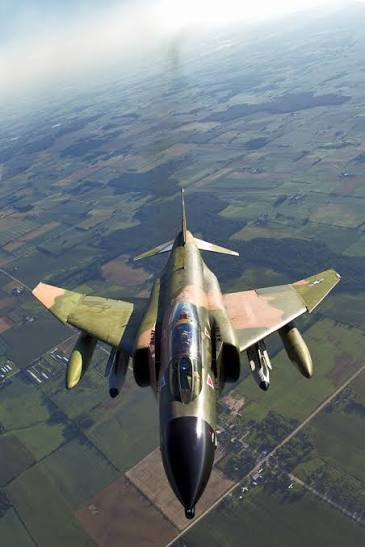

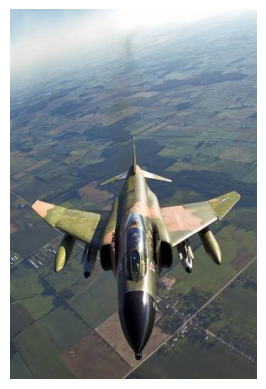

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
[[1.19317025e-04 1.63282210e-04 1.52273264e-04 2.80364708e-04
  1.10151697e-04 6.22265448e-04 2.05639008e-04 1.28808024e-04
  7.08528241e-05 9.98147011e-01]]
9
The object is: airplane


In [54]:
input_img_path = input("Enter image path: ")

input_image = cv2.imread(input_img_path)

if input_image is None:
    print("Image not loaded. Check the file path.")
else:
    cv2_imshow(input_image)

    input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
    plt.imshow(input_image_rgb)
    plt.axis("off")
    plt.show()

    input_image_resized = cv2.resize(input_image_rgb, (32, 32))
    input_image_scaled = input_image_resized / 255.0
    input_image_reshaped = np.reshape(input_image_scaled, [1, 32, 32, 3])

    input_prediction = model.predict(input_image_reshaped)
    print(input_prediction)

    input_pred_label = np.argmax(input_prediction)
    print(input_pred_label)

    class_names = ['frog', 'truck', 'deer', 'automobile', 'bird',
                   'horse', 'ship', 'cat', 'dog', 'airplane']

    print("The object is:", class_names[input_pred_label])

In [52]:
print(model)

<Sequential name=sequential_1, built=True>


In [56]:
model.save('/content/my_model.h5')